# **PRAKTIKUM PERTEMUAN 4 DATA SCIENCE**

Nama : Ninis Indah Trisia

NIM : 250401020094

Kelas : IF405

### Langkah 1: Load & Inspect Dataset

In [ ]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#load dataset iris
df = sns.load_dataset('iris')

#menampilkan jumlah baris dan kolom
print('Shape:', df.shape)
#menampilkan tipe data tiap kolom
print(df.dtypes)
#menampilkan 5 data pertama
print(df.head())
#menampilkan ringkasan statistik
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

### Langkah 2: Statistik Deskriptif Lengkap

In [ ]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'Mean      : {col.mean():.3f}')
    print(f'Median    : {col.median():.3f}')
    print(f'Std Dev   : {col.std():.3f}')
    print(f'Varians   : {col.var():.3f}')
    print(f'Skewness  : {col.skew():.3f}')
    print(f'Kurtosis  : {col.kurt():.3f}')


=== sepal_length ===
Mean      : 5.843
Median    : 5.800
Std Dev   : 0.828
Varians   : 0.686
Skewness  : 0.315
Kurtosis  : -0.552

=== sepal_width ===
Mean      : 3.057
Median    : 3.000
Std Dev   : 0.436
Varians   : 0.190
Skewness  : 0.319
Kurtosis  : 0.228

=== petal_length ===
Mean      : 3.758
Median    : 4.350
Std Dev   : 1.765
Varians   : 3.116
Skewness  : -0.275
Kurtosis  : -1.402

=== petal_width ===
Mean      : 1.199
Median    : 1.300
Std Dev   : 0.762
Varians   : 0.581
Skewness  : -0.103
Kurtosis  : -1.341


### Langkah 3: Analisis Distribusi

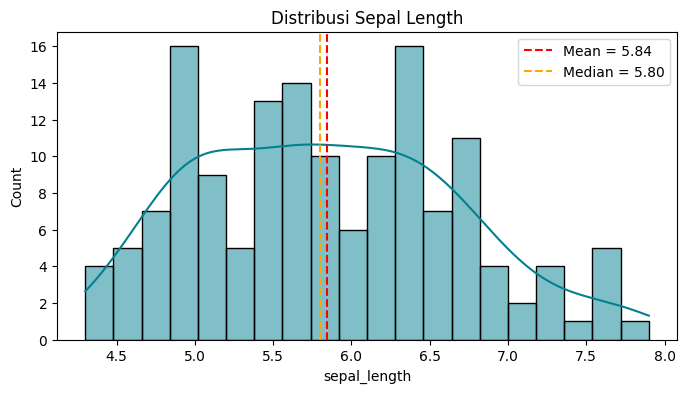

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    color='#028090',
    bins=20,
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length')
ax.legend()

plt.show()

### Langkah 4: Boxplot per Spesies

/tmp/ipykernel_985/1552083014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_985/1552083014.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


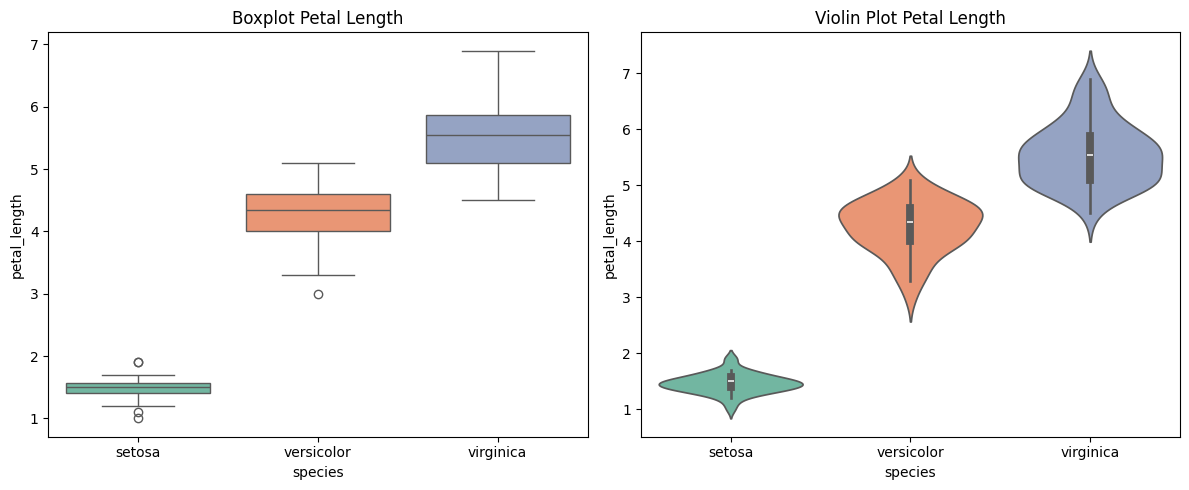

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Boxplot Petal Length')

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

### Langkah 5: Matriks Korelasi Pearson

In [ ]:
# Menghitung korelasi Pearson
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

# Mencari pasangan korelasi tertinggi
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'\nKorelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


### Langkah 6: Scatter Plot & Heatmap

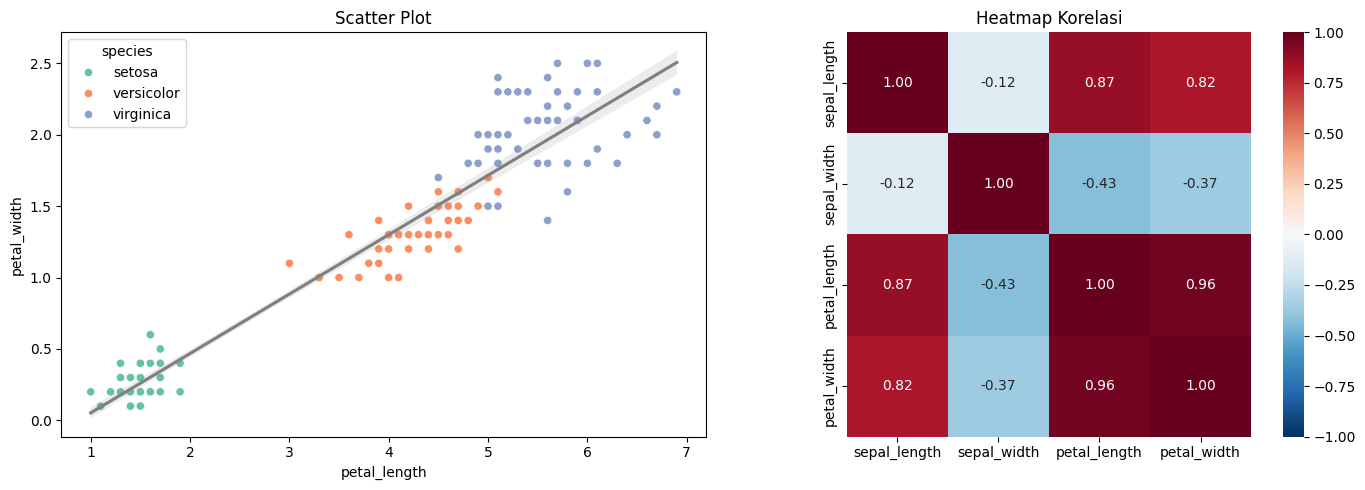

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter Plot')

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

##Kesimpulan

Pada praktikum ini saya mempelajari cara melakukan analisis statistik deskriptif dan visualisasi data menggunakan dataset Iris. Langkah awal yang dilakukan adalah mengenali struktur dataset, melihat tipe data, serta memahami karakteristik setiap variabel melalui ringkasan statistik seperti nilai rata-rata, median, standar deviasi, varians, skewness, dan kurtosis.

Selanjutnya, saya mempelajari distribusi data dengan menggunakan histogram yang dilengkapi kurva KDE, sehingga dapat melihat bagaimana persebaran nilai pada variabel sepal length. Perbandingan antara nilai mean dan median juga membantu dalam memahami apakah data cenderung simetris atau memiliki kemiringan tertentu.

Pada tahap berikutnya, boxplot dan violin plot digunakan untuk membandingkan panjang petal pada masing-masing spesies bunga iris. Dari visualisasi tersebut terlihat bahwa setiap spesies memiliki karakteristik ukuran petal yang berbeda sehingga dapat membantu dalam membedakan antarspesies.

Analisis korelasi Pearson menunjukkan adanya hubungan yang cukup kuat antara beberapa variabel. Hubungan antara petal length dan petal width terlihat paling tinggi, yang berarti ketika panjang petal meningkat, lebar petal juga cenderung meningkat. Hasil ini juga diperkuat melalui scatter plot dan heatmap yang memperlihatkan pola hubungan antarvariabel secara lebih jelas.

Melalui praktikum ini saya menjadi lebih memahami bagaimana statistik deskriptif dan visualisasi dapat digunakan untuk mengeksplorasi data sebelum melakukan analisis yang lebih lanjut. Saya juga belajar bahwa grafik dan matriks korelasi sangat membantu dalam menemukan pola, hubungan, serta karakteristik penting yang terdapat dalam suatu dataset.